In [1]:
%pip install torch torchvision torchaudio scikit-learn pandas matplotlib


Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from torch.utils.data import TensorDataset,DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("customers.csv")
df

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A
...,...,...,...,...,...,...,...,...,...,...,...
10690,467954,Male,No,29,No,Healthcare,9.0,Low,4.0,Cat_6,B
10691,467958,Female,No,35,Yes,Doctor,1.0,Low,1.0,Cat_6,A
10692,467960,Female,No,53,Yes,Entertainment,NaN,Low,2.0,Cat_6,C
10693,467961,Male,Yes,47,Yes,Executive,1.0,High,5.0,Cat_4,C


In [4]:
df=df.drop(columns=["ID"])
df

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A
...,...,...,...,...,...,...,...,...,...,...
10690,Male,No,29,No,Healthcare,9.0,Low,4.0,Cat_6,B
10691,Female,No,35,Yes,Doctor,1.0,Low,1.0,Cat_6,A
10692,Female,No,53,Yes,Entertainment,NaN,Low,2.0,Cat_6,C
10693,Male,Yes,47,Yes,Executive,1.0,High,5.0,Cat_4,C


In [5]:
df.columns

Index(['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1',
       'Segmentation'],
      dtype='str')

In [6]:
df.fillna({"Work_Experience":0,"Family_Size":df["Family_Size"].median()},inplace=True)
df

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,Female,Yes,38,Yes,Engineer,0.0,Average,3.0,Cat_4,A
2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,Female,Yes,40,Yes,Entertainment,0.0,High,6.0,Cat_6,A
...,...,...,...,...,...,...,...,...,...,...
10690,Male,No,29,No,Healthcare,9.0,Low,4.0,Cat_6,B
10691,Female,No,35,Yes,Doctor,1.0,Low,1.0,Cat_6,A
10692,Female,No,53,Yes,Entertainment,0.0,Low,2.0,Cat_6,C
10693,Male,Yes,47,Yes,Executive,1.0,High,5.0,Cat_4,C


In [7]:
cat_columns=['Gender','Ever_Married', 'Graduated', 'Profession',
    'Spending_Score', 'Var_1']
for col in cat_columns:
    df[col]=LabelEncoder().fit_transform(df[col])

In [8]:
lbe=LabelEncoder()
df["Segmentation"]=lbe.fit_transform(df["Segmentation"])
df

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,1,0,22,0,5,1.0,2,4.0,3,3
1,0,1,38,1,2,0.0,0,3.0,3,0
2,0,1,67,1,2,1.0,2,1.0,5,1
3,1,1,67,1,7,0.0,1,2.0,5,1
4,0,1,40,1,3,0.0,1,6.0,5,0
...,...,...,...,...,...,...,...,...,...,...
10690,1,0,29,0,5,9.0,2,4.0,5,1
10691,0,0,35,1,1,1.0,2,1.0,5,0
10692,0,0,53,1,3,0.0,2,2.0,5,2
10693,1,1,47,1,4,1.0,1,5.0,3,2


In [9]:
x=df.drop(columns="Segmentation")
y=df["Segmentation"].values
xt,xst,yt,yst=train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
scaler=StandardScaler()
xt=scaler.fit_transform(xt)
xst=scaler.transform(xst)

In [11]:
xt=torch.FloatTensor(xt)
xst=torch.FloatTensor(xst)
yt=torch.FloatTensor(yt)
yst=torch.FloatTensor(yst)

In [12]:
tr=TensorDataset(xt,yt)
tst=TensorDataset(xst,yst)
trl=DataLoader(tr,batch_size=16,shuffle=True)
tstl=DataLoader(tst,batch_size=16)

In [13]:
class classifier1(nn.Module):
    def __init__(self,input_size):
        super().__init__()
        self.l1=nn.Linear(input_size,32)
        self.l2=nn.Linear(32,16)
        self.l3=nn.Linear(16,8)
        self.l4=nn.Linear(8,4)
    def forward(self,x):
        x=F.relu(self.l1(x))
        x=F.relu(self.l2(x))
        x=F.relu(self.l3(x))
        x=self.l4(x)
        return x


In [14]:
model=classifier1(input_size=xt.shape[1])
criterion=nn.CrossEntropyLoss()
op=optim.Adam(model.parameters(),lr=0.001)

In [15]:
epochs=100
for i in range(epochs):
    for a,b in trl:
        op.zero_grad()
        pred=model(a)
        loss=criterion(pred,b.long())
        loss.backward()
        op.step()
    if i%10==0:
        print(f"Loss:{i}/{epochs}",loss.item())



Loss:0/100 1.115470051765442
Loss:10/100 1.302460789680481
Loss:20/100 1.1261612176895142
Loss:30/100 1.3509258031845093
Loss:40/100 1.2130399942398071
Loss:50/100 0.7676439881324768
Loss:60/100 1.0218310356140137
Loss:70/100 0.9057972431182861
Loss:80/100 1.0553228855133057
Loss:90/100 1.298378586769104


In [16]:
pre=[]
act=[]
with torch.no_grad():
    output=model(xst)
    _,predicted=torch.max(output,1)
    pre.extend(predicted.numpy())
    act.extend(yst.numpy())
    print(act,pre)


[np.float32(1.0), np.float32(3.0), np.float32(1.0), np.float32(1.0), np.float32(1.0), np.float32(3.0), np.float32(3.0), np.float32(3.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(3.0), np.float32(3.0), np.float32(1.0), np.float32(3.0), np.float32(2.0), np.float32(1.0), np.float32(3.0), np.float32(1.0), np.float32(3.0), np.float32(3.0), np.float32(0.0), np.float32(3.0), np.float32(2.0), np.float32(1.0), np.float32(3.0), np.float32(3.0), np.float32(0.0), np.float32(1.0), np.float32(1.0), np.float32(3.0), np.float32(0.0), np.float32(0.0), np.float32(2.0), np.float32(1.0), np.float32(2.0), np.float32(1.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(3.0), np.float32(2.0), np.float32(1.0), np.float32(3.0), np.float32(2.0), np.float32(2.0), np.float32(3.0), np.float32(2.0), np.float32(3.0), np.float32(2.0), np.float32(1.0), np.float32(1.0), np.float32(3.0), np.float32(2.0), np.float32(3.0), np.float32(2.0), np.float32(1.0), np.float32(0.0), np.float32(1.

In [17]:
accuracy=accuracy_score(act,pre)
conf_matrix=confusion_matrix(act,pre)
cl_report=classification_report(act,pre,target_names=['A','B','C','D'])
print("Accuracy:",accuracy)
print("confusion_matrix:\n",conf_matrix)
print("classification_report:\n",cl_report)


Accuracy: 0.47639083683964467
confusion_matrix:
 [[233  96  95 160]
 [145 130 138  77]
 [ 89  67 253  63]
 [135  29  26 403]]
classification_report:
               precision    recall  f1-score   support

           A       0.39      0.40      0.39       584
           B       0.40      0.27      0.32       490
           C       0.49      0.54      0.51       472
           D       0.57      0.68      0.62       593

    accuracy                           0.48      2139
   macro avg       0.46      0.47      0.46      2139
weighted avg       0.47      0.48      0.47      2139



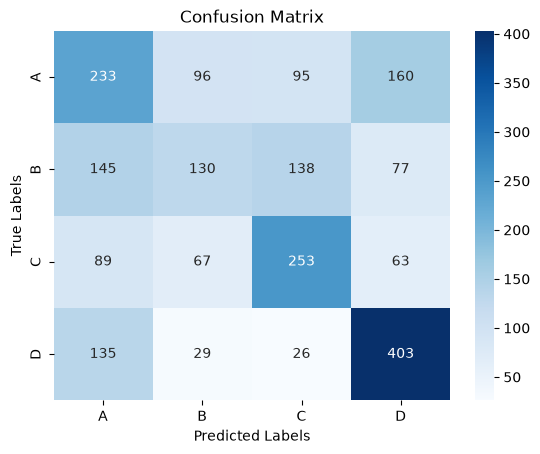

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
xl=['A','B','C','D']
sns.heatmap(conf_matrix, annot=True, cmap='Blues', xticklabels=xl, yticklabels=xl,fmt='g')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

In [22]:
sample_input = xst[12].clone().unsqueeze(0).detach().type(torch.float32)
model.eval()

with torch.no_grad():
    output = model(sample_input)
    predicted_class_index = torch.argmax(output[0]).item()

predicted_class_label = lbe.inverse_transform(
    [predicted_class_index]
)[0]

actual_class_index = int(yst[12].item())
actual_class_label = lbe.inverse_transform(
    [actual_class_index]
)[0]

print(f'Predicted class for sample input: {predicted_class_label}')
print(f'Actual class for sample input: {actual_class_label}')

Predicted class for sample input: D
Actual class for sample input: D
